In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('../data/processed/rossmann_features.csv', parse_dates=['Date'])
print("Loaded:", df.shape)

Loaded: (844338, 37)


In [3]:
## Drop rows with NaN from lag features (first 30 days per store)
df = df.dropna(subset=['Sales_Lag7','Sales_Lag14','Sales_Lag30',
                        'Sales_MA7','Sales_MA30'])
print("After dropping lag NaNs:", df.shape)

After dropping lag NaNs: (810888, 37)


In [4]:
## TIME-BASED SPLIT — last 2 months = test
split_date = '2015-05-01'
train = df[df['Date'] < split_date].copy()
test  = df[df['Date'] >= split_date].copy()
print(f"Train: {train.shape}, Test: {test.shape}")
print(f"Train period: {train['Date'].min()} to {train['Date'].max()}")
print(f"Test period:  {test['Date'].min()} to {test['Date'].max()}")

Train: (726398, 37), Test: (84490, 37)
Train period: 2013-01-31 00:00:00 to 2015-04-30 00:00:00
Test period:  2015-05-01 00:00:00 to 2015-07-31 00:00:00


In [5]:
FEATURES = [
    'Store', 'DayOfWeek', 'Promo', 'SchoolHoliday',
    'Year', 'Month', 'Week', 'DayOfMonth', 'IsWeekend', 'Quarter',
    'Sales_Lag7', 'Sales_Lag14', 'Sales_Lag30',
    'Sales_MA7', 'Sales_MA30',
    'Store_AvgSales', 'Store_StdSales',
    'Promo_Weekend', 'StoreType_enc', 'Assortment_enc',
    'StateHoliday_enc', 'CompetitionDistance', 'HasCompetition',
    'CompetitionDistance_log', 'Promo2'
]

In [6]:
X_train = train[FEATURES]
y_train = train['Sales']
X_test  = test[FEATURES]
y_test  = test['Sales']

In [8]:
print("Training Random Forest...")
rf = RandomForestRegressor(
    n_estimators=100,
    max_depth=15,
    min_samples_leaf=10,
    n_jobs=-1,        # use all CPU cores
    random_state=42
)
rf.fit(X_train, y_train)
print("Training complete!")

Training Random Forest...
Training complete!


In [9]:
## --- METRICS ---
y_pred = rf.predict(X_test)

In [10]:
mae  = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
## RMSPE — Rossmann's official metric
def rmspe(y_true, y_pred):
    mask = y_true != 0
    return np.sqrt(np.mean(((y_true[mask] - y_pred[mask]) / y_true[mask])**2))

In [11]:
rmspe_score = rmspe(y_test.values, y_pred)

In [12]:
print(f"MAE:   {mae:.2f}")
print(f"RMSE:  {rmse:.2f}")
print(f"RMSPE: {rmspe_score:.4f}  ({rmspe_score*100:.2f}%)")

MAE:   728.95
RMSE:  1040.44
RMSPE: 0.1538  (15.38%)


In [13]:
## --- PLOT: Actual vs Predicted ---
sample = test[test['Store'] == 1].copy()
sample_pred = rf.predict(sample[FEATURES])

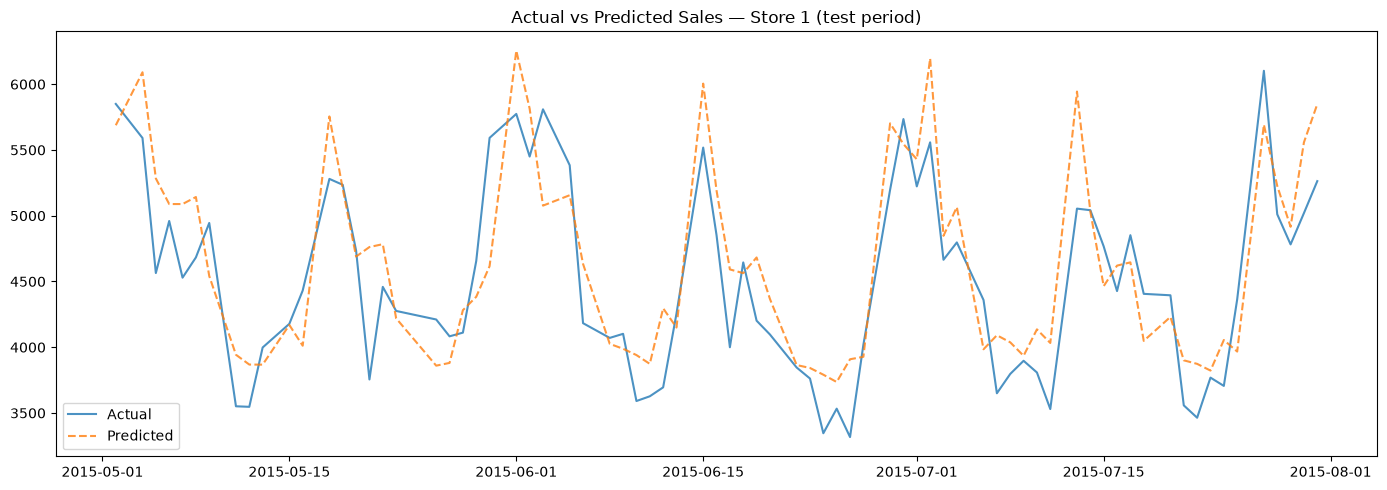

In [14]:
plt.figure(figsize=(14, 5))
plt.plot(sample['Date'].values, sample['Sales'].values,
         label='Actual', alpha=0.8)
plt.plot(sample['Date'].values, sample_pred,
         label='Predicted', alpha=0.8, linestyle='--')
plt.title('Actual vs Predicted Sales — Store 1 (test period)')
plt.legend()
plt.tight_layout()
plt.savefig('../reports/actual_vs_predicted.png')
plt.show()

In [15]:
importances = pd.Series(rf.feature_importances_, index=FEATURES)
importances = importances.sort_values(ascending=True)

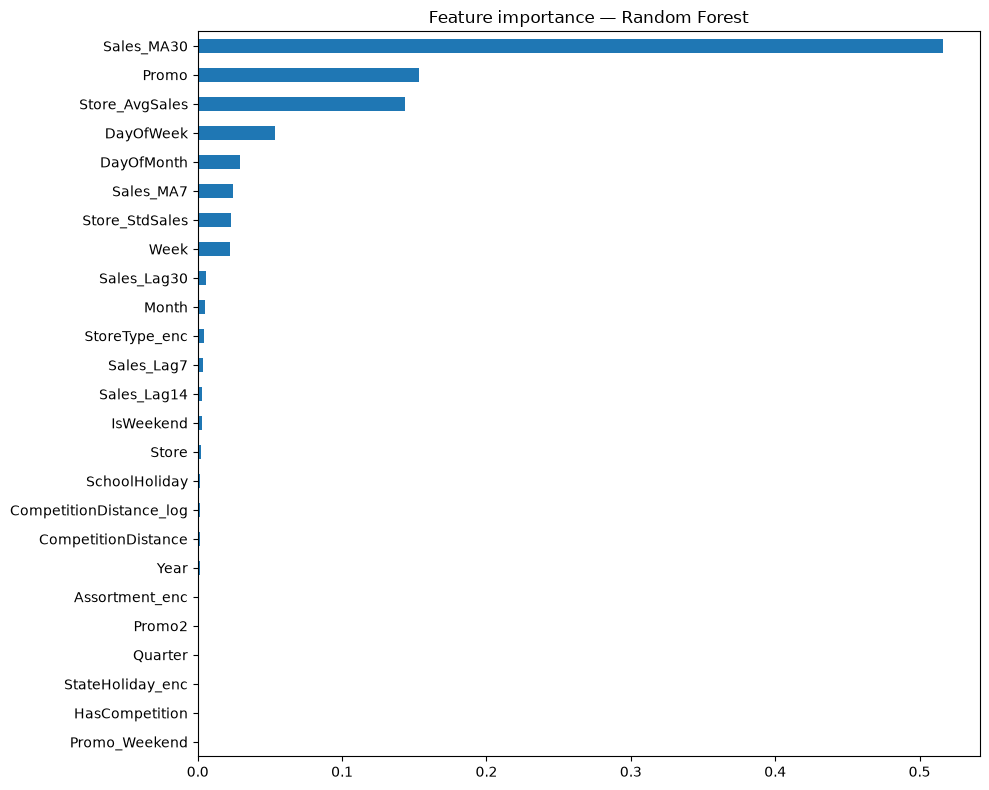

In [16]:
plt.figure(figsize=(10, 8))
importances.plot(kind='barh')
plt.title('Feature importance — Random Forest')
plt.tight_layout()
plt.savefig('../reports/feature_importance.png')
plt.show()

In [17]:
## Add predictions to test set
test = test.copy()
test['Predicted_Sales'] = y_pred

In [18]:
## Monthly forecast summary by store
monthly = test.groupby(['Store', pd.Grouper(key='Date', freq='ME')]).agg(
    Actual_Sales=('Sales', 'sum'),
    Predicted_Sales=('Predicted_Sales', 'sum')
).reset_index()

In [19]:
print("Monthly forecast sample:")
print(monthly.head(10))

Monthly forecast sample:
   Store       Date  Actual_Sales  Predicted_Sales
0      1 2015-05-31        105220    107219.991795
1      1 2015-06-30        110011    114928.314110
2      1 2015-07-31        121266    125600.257830
3      2 2015-05-31        115535    114168.658373
4      2 2015-06-30        132800    132380.078884
5      2 2015-07-31        133765    137466.574803
6      3 2015-05-31        164244    162472.053119
7      3 2015-06-30        189918    180029.163393
8      3 2015-07-31        183535    188838.183460
9      4 2015-05-31        232948    230551.194591


In [21]:
# Top 10 stores by predicted sales
top_stores = test.groupby('Store')['Predicted_Sales'].sum().sort_values(ascending=False).head(10)
print("Top 10 stores by predicted total sales:")
print(top_stores)

Top 10 stores by predicted total sales:
Store
262     1.969871e+06
1114    1.668571e+06
562     1.646812e+06
817     1.616504e+06
842     1.513984e+06
251     1.457028e+06
733     1.403649e+06
788     1.392745e+06
513     1.370781e+06
383     1.299178e+06
Name: Predicted_Sales, dtype: float64


In [22]:
# Save forecast
test[['Date','Store','Sales','Predicted_Sales']].to_csv(
    '../data/processed/sales_forecast.csv', index=False)
print("Forecast saved.")

Forecast saved.
